In [1]:
import pandas as pd
import matplotlib.pylab as plt
import numpy as np

In [2]:
df = pd.read_csv("autodata.csv")

In [3]:
df.head(5)

,Unnamed: 0,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Low,0,1
1,1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Low,0,1
2,2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,3,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Low,0,1
4,4,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Low,0,1


In [4]:
df.tail(5)

,Unnamed: 0,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
196,196,-1,95,volvo,std,four,sedan,rwd,front,109.1,...,9.5,114.0,5400.0,23,28,16845.0,10.217391,Low,0,1
197,197,-1,95,volvo,turbo,four,sedan,rwd,front,109.1,...,8.7,160.0,5300.0,19,25,19045.0,12.368421,Medium,0,1
198,198,-1,95,volvo,std,four,sedan,rwd,front,109.1,...,8.8,134.0,5500.0,18,23,21485.0,13.055556,Medium,0,1
199,199,-1,95,volvo,turbo,four,sedan,rwd,front,109.1,...,23.0,106.0,4800.0,26,27,22470.0,9.038462,Low,1,0
200,200,-1,95,volvo,turbo,four,sedan,rwd,front,109.1,...,9.5,114.0,5400.0,19,25,22625.0,12.368421,Low,0,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         201 non-null    int64  
 1   symboling          201 non-null    int64  
 2   normalized-losses  201 non-null    int64  
 3   make               201 non-null    str    
 4   aspiration         201 non-null    str    
 5   num-of-doors       201 non-null    str    
 6   body-style         201 non-null    str    
 7   drive-wheels       201 non-null    str    
 8   engine-location    201 non-null    str    
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    str    
 15  num-of-cylinders   201 non-null    str    
 16  engine-size        201 non-null    in

In [6]:
df.describe()

,Unnamed: 0,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
count,201.000000,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,201.000000,199.000000,199.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,100.000000,0.840796,122.00000,98.797015,0.837102,0.915126,53.766667,2555.666667,126.875622,3.330692,3.256904,10.164279,103.396985,5117.587940,25.179104,30.686567,13207.129353,9.944145,0.099502,0.900498
std,58.167861,1.254802,31.99625,6.066366,0.059213,0.029187,2.447822,517.296727,41.546834,0.268072,0.319256,4.004965,37.553843,480.521824,6.423220,6.815150,7947.066342,2.534599,0.300083,0.300083
min,0.000000,-2.000000,65.00000,86.600000,0.678039,0.837500,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,0.000000,0.000000
25%,50.000000,0.000000,101.00000,94.500000,0.801538,0.890278,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,7.833333,0.000000,1.000000
50%,100.000000,1.000000,122.00000,97.000000,0.832292,0.909722,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000,9.791667,0.000000,1.000000
75%,150.000000,2.000000,137.00000,102.400000,0.881788,0.925000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421,0.000000,1.000000
max,200.000000,3.000000,256.00000,120.900000,1.000000,1.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,18.076923,1.000000,1.000000


In [7]:
df.isnull()

,Unnamed: 0,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
197,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
198,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
199,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [51]:
df.isna()

,Unnamed: 0,symboling,normalized-losses,make,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,price,city-L/100km,horsepower-binned,diesel,gas,highway-L/100km,std,turbo,peakrpm-binned,wheelbase-binned
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
195,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
196,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
197,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Unnamed: 0           0
symboling            0
normalized-losses    0
make                 0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               4
compression-ratio    0
horsepower           2
peak-rpm             2
city-mpg             0
highway-mpg          0
price                0
city-L/100km         0
horsepower-binned    2
diesel               0
gas                  0
dtype: int64

In [9]:
df.notnull()

,Unnamed: 0,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
197,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
198,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
199,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


In [10]:
df.notnull().sum()

Unnamed: 0           201
symboling            201
normalized-losses    201
make                 201
aspiration           201
num-of-doors         201
body-style           201
drive-wheels         201
engine-location      201
wheel-base           201
length               201
width                201
height               201
curb-weight          201
engine-type          201
num-of-cylinders     201
engine-size          201
fuel-system          201
bore                 201
stroke               197
compression-ratio    201
horsepower           199
peak-rpm             199
city-mpg             201
highway-mpg          201
price                201
city-L/100km         201
horsepower-binned    199
diesel               201
gas                  201
dtype: int64

In [11]:
# calculate the mean vaule for "stroke" column
avg_stroke = df["stroke"].astype("float").mean(axis = 0)
print("Average of stroke:", avg_stroke)

# replace NaN by mean value in "stroke" column
df["stroke"].replace(np.nan, avg_stroke, inplace = True)

Average of stroke: 3.256903553299492


/var/folders/t6/2401qcw969qf50m6zwvsqbm80000gn/T/ipykernel_4049/788029539.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["stroke"].replace(np.nan, avg_stroke, inplace = True)


0      2.68
1      2.68
2      3.47
3      3.40
4      3.40
       ... 
196    3.15
197    3.15
198    2.87
199    3.40
200    3.15
Name: stroke, Length: 201, dtype: float64

Calculate the mean value for the 'horsepower' column:

In [12]:
avg_hp = df["horsepower"].astype("float").mean(axis = 0)
print("Average of stroke:", avg_hp)

Average of stroke: 103.39698492462311


Replace "NaN" by mean value:

In [13]:
df["horsepower"].replace(np.nan, avg_hp, inplace = True)

/var/folders/t6/2401qcw969qf50m6zwvsqbm80000gn/T/ipykernel_4049/1934941934.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["horsepower"].replace(np.nan, avg_hp, inplace = True)


0      111.0
1      111.0
2      154.0
3      102.0
4      115.0
       ...  
196    114.0
197    160.0
198    134.0
199    106.0
200    114.0
Name: horsepower, Length: 201, dtype: float64

Calculate the mean value for 'peak-rpm' column:

In [14]:
avg_rpm = df["peak-rpm"].astype("float").mean(axis = 0)
print("Average of stroke:", avg_rpm)

Average of stroke: 5117.587939698493


Replace NaN by mean value:

In [15]:
df["peak-rpm"].replace(np.nan, avg_hp, inplace = True)

/var/folders/t6/2401qcw969qf50m6zwvsqbm80000gn/T/ipykernel_4049/648489743.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["peak-rpm"].replace(np.nan, avg_hp, inplace = True)


0      5000.0
1      5000.0
2      5000.0
3      5500.0
4      5500.0
        ...  
196    5400.0
197    5300.0
198    5500.0
199    4800.0
200    5400.0
Name: peak-rpm, Length: 201, dtype: float64

In [16]:
df['num-of-doors'].value_counts()

num-of-doors
four    115
two      86
Name: count, dtype: int64

In [17]:
df['num-of-doors'].value_counts().idxmax()

'four'

In [18]:
 df["num-of-doors"].replace(np.nan, "four", inplace=True)

df.dropna(subset=["horsepower-binned"], axis=0, inplace=True)

df.reset_index(drop=True, inplace=True)

/var/folders/t6/2401qcw969qf50m6zwvsqbm80000gn/T/ipykernel_4049/4028301071.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["num-of-doors"].replace(np.nan, "four", inplace=True)


In [19]:
df.isnull().sum()

Unnamed: 0           0
symboling            0
normalized-losses    0
make                 0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               4
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
city-L/100km         0
horsepower-binned    0
diesel               0
gas                  0
dtype: int64

Here, we can see that there are no missing values in the data.

##Part-2

In [20]:
df['city-L/100km'] = 235/df["city-mpg"]
df.head()

,Unnamed: 0,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Low,0,1
1,1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Low,0,1
2,2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,3,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Low,0,1
4,4,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Low,0,1


In [21]:
df['highway-L/100km'] = 235/df["highway-mpg"]
df.head()

,Unnamed: 0,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas,highway-L/100km
0,0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,111.0,5000.0,21,27,13495.0,11.190476,Low,0,1,8.703704
1,1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,111.0,5000.0,21,27,16500.0,11.190476,Low,0,1,8.703704
2,2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,...,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1,9.038462
3,3,2,164,audi,std,four,sedan,fwd,front,99.8,...,102.0,5500.0,24,30,13950.0,9.791667,Low,0,1,7.833333
4,4,2,164,audi,std,four,sedan,4wd,front,99.4,...,115.0,5500.0,18,22,17450.0,13.055556,Low,0,1,10.681818


In [22]:
df['length'] = df['length']/df['length'].max()
df['width'] = df['width']/df['width'].max()

In [23]:
df['height'] = df['height']/df['height'].max() 
df[["length","width","height"]].head()

,length,width,height
0,0.811148,0.890278,0.816054
1,0.811148,0.890278,0.816054
2,0.822681,0.909722,0.876254
3,0.848630,0.919444,0.908027
4,0.848630,0.922222,0.908027


In [24]:
df.columns

Index(['Unnamed: 0', 'symboling', 'normalized-losses', 'make', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price', 'city-L/100km', 'horsepower-binned', 'diesel',
       'gas', 'highway-L/100km'],
      dtype='str')

In [25]:
df['aspiration'].value_counts()

aspiration
std      163
turbo     36
Name: count, dtype: int64

In [26]:
dummy_variable_1 = pd.get_dummies(df["aspiration"])
dummy_variable_1.head()

,std,turbo
0,True,False
1,True,False
2,True,False
3,True,False
4,True,False


In [27]:
df = pd.concat([df, dummy_variable_1], axis=1)
df.drop("aspiration", axis = 1, inplace=True)

In [28]:
df.head()

,Unnamed: 0,symboling,normalized-losses,make,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas,highway-L/100km,std,turbo
0,0,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,...,21,27,13495.0,11.190476,Low,0,1,8.703704,True,False
1,1,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,...,21,27,16500.0,11.190476,Low,0,1,8.703704,True,False
2,2,1,122,alfa-romero,two,hatchback,rwd,front,94.5,0.822681,...,19,26,16500.0,12.368421,Medium,0,1,9.038462,True,False
3,3,2,164,audi,four,sedan,fwd,front,99.8,0.848630,...,24,30,13950.0,9.791667,Low,0,1,7.833333,True,False
4,4,2,164,audi,four,sedan,4wd,front,99.4,0.848630,...,18,22,17450.0,13.055556,Low,0,1,10.681818,True,False


The last two columns are now the indicator variable representation of the aspiration variable. It's all 0s and 1s now.

In [29]:
df["horsepower"]=df["horsepower"].astype(float, copy=True)

/var/folders/t6/2401qcw969qf50m6zwvsqbm80000gn/T/ipykernel_4049/587232981.py:1: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df["horsepower"]=df["horsepower"].astype(float, copy=True)


Text(0.5, 1.0, 'horsepower bins')

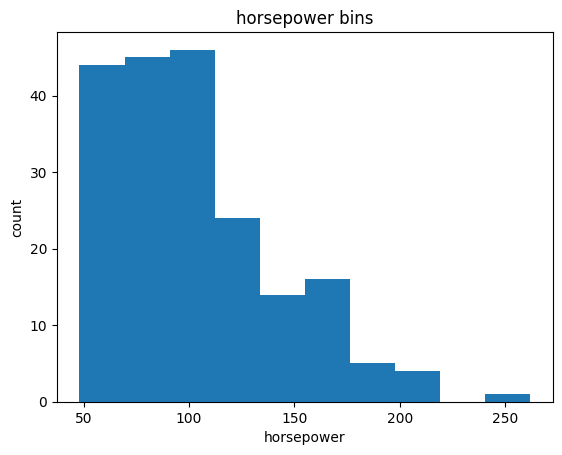

In [30]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot
plt.pyplot.hist(df["horsepower"])

plt.pyplot.xlabel("horsepower")
plt.pyplot.ylabel("count")
plt.pyplot.title("horsepower bins")

In [31]:
bins = np.linspace(min(df["horsepower"]), max(df["horsepower"]), 4)
bins

array([ 48.        , 119.33333333, 190.66666667, 262.        ])

In [32]:
group_names = ['Low', 'Medium', 'High']

In [33]:
df['horsepower-binned'] = pd.cut(df['horsepower'], bins, labels=group_names, include_lowest=True )
df[['horsepower','horsepower-binned']].head(20)

,horsepower,horsepower-binned
0,111.0,Low
1,111.0,Low
2,154.0,Medium
3,102.0,Low
4,115.0,Low
5,110.0,Low
6,110.0,Low
7,110.0,Low
8,140.0,Medium
9,101.0,Low


In [34]:
df["horsepower-binned"].value_counts()

horsepower-binned
Low       151
Medium     43
High        5
Name: count, dtype: int64

Text(0.5, 1.0, 'horsepower bins')

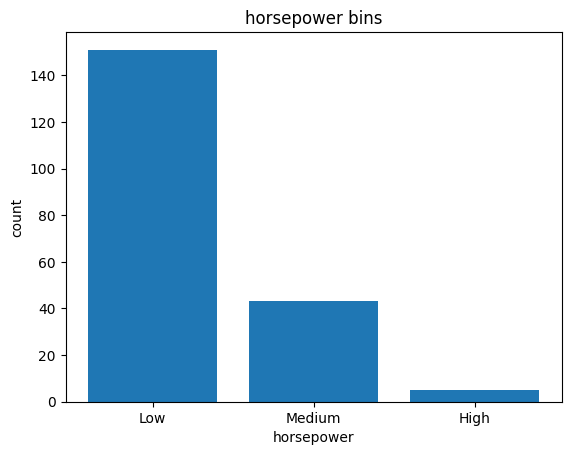

In [35]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot
pyplot.bar(group_names, df["horsepower-binned"].value_counts())

# set x/y labels and plot title
plt.pyplot.xlabel("horsepower")
plt.pyplot.ylabel("count")
plt.pyplot.title("horsepower bins")

### Peak-rpm

In [36]:
df["peak-rpm"]=df["peak-rpm"].astype(float, copy=True)

/var/folders/t6/2401qcw969qf50m6zwvsqbm80000gn/T/ipykernel_4049/2606585263.py:1: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df["peak-rpm"]=df["peak-rpm"].astype(float, copy=True)


Text(0.5, 1.0, 'Peak-rpm bins')

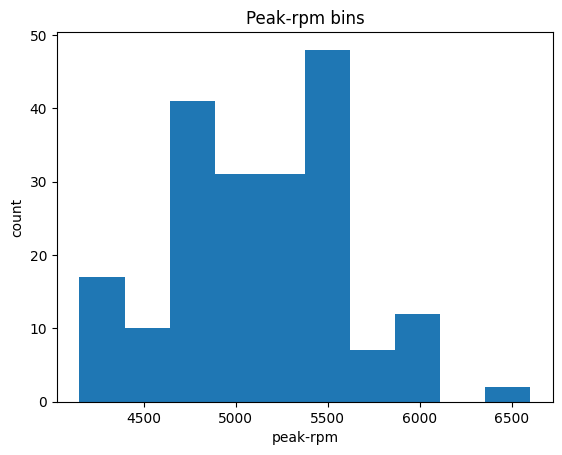

In [37]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot
plt.pyplot.hist(df["peak-rpm"])

plt.pyplot.xlabel("peak-rpm")
plt.pyplot.ylabel("count")
plt.pyplot.title("Peak-rpm bins")

In [38]:
bins = np.linspace(min(df["peak-rpm"]), max(df["peak-rpm"]), 4)
bins

array([4150.        , 4966.66666667, 5783.33333333, 6600.        ])

In [39]:
group_names1 = ['Low', 'Medium', 'High']

In [40]:
df['peakrpm-binned'] = pd.cut(df['peak-rpm'], bins, labels=group_names, include_lowest=True )
df[['peak-rpm','peakrpm-binned']].head(20)

,peak-rpm,peakrpm-binned
0,5000.0,Medium
1,5000.0,Medium
2,5000.0,Medium
3,5500.0,Medium
4,5500.0,Medium
5,5500.0,Medium
6,5500.0,Medium
7,5500.0,Medium
8,5500.0,Medium
9,5800.0,High


In [41]:
df["peakrpm-binned"].value_counts()

peakrpm-binned
Medium    109
Low        69
High       21
Name: count, dtype: int64

Text(0.5, 1.0, 'peak-rpm bins')

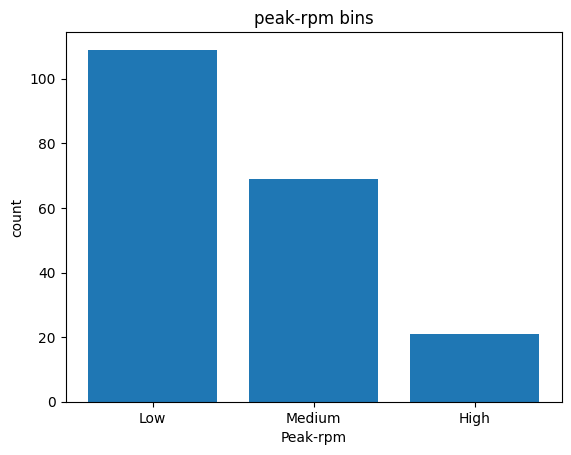

In [42]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot
pyplot.bar(group_names, df["peakrpm-binned"].value_counts())

# set x/y labels and plot title
plt.pyplot.xlabel("Peak-rpm")
plt.pyplot.ylabel("count")
plt.pyplot.title("peak-rpm bins")

### Wheel-base

In [43]:
df["wheel-base"]=df["wheel-base"].astype(float, copy=True)

/var/folders/t6/2401qcw969qf50m6zwvsqbm80000gn/T/ipykernel_4049/3573911376.py:1: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df["wheel-base"]=df["wheel-base"].astype(float, copy=True)


Text(0.5, 1.0, 'Wheel-base bins')

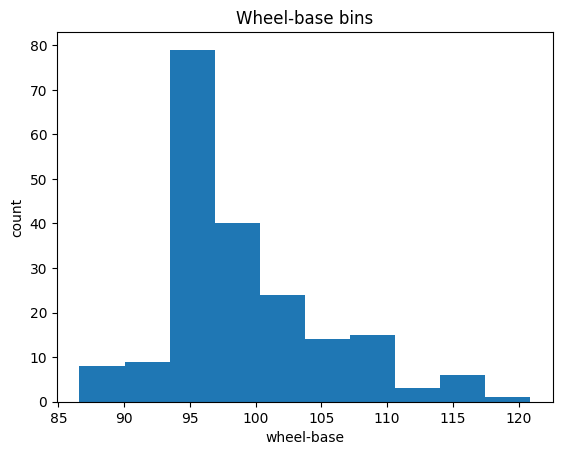

In [44]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot
plt.pyplot.hist(df["wheel-base"])

plt.pyplot.xlabel("wheel-base")
plt.pyplot.ylabel("count")
plt.pyplot.title("Wheel-base bins")

In [45]:
bins = np.linspace(min(df["wheel-base"]), max(df["wheel-base"]), 4)
bins

array([ 86.6       ,  98.03333333, 109.46666667, 120.9       ])

In [46]:
group_names = ['Low', 'Medium', 'High']

In [47]:
df['wheelbase-binned'] = pd.cut(df['wheel-base'], bins, labels=group_names, include_lowest=True )
df[['wheel-base','wheelbase-binned']].head(20)

,wheel-base,wheelbase-binned
0,88.6,Low
1,88.6,Low
2,94.5,Low
3,99.8,Medium
4,99.4,Medium
5,99.8,Medium
6,105.8,Medium
7,105.8,Medium
8,105.8,Medium
9,101.2,Medium


In [48]:
df["wheelbase-binned"].value_counts()

wheelbase-binned
Low       114
Medium     72
High       13
Name: count, dtype: int64

Text(0.5, 1.0, 'Wheelbase bins')

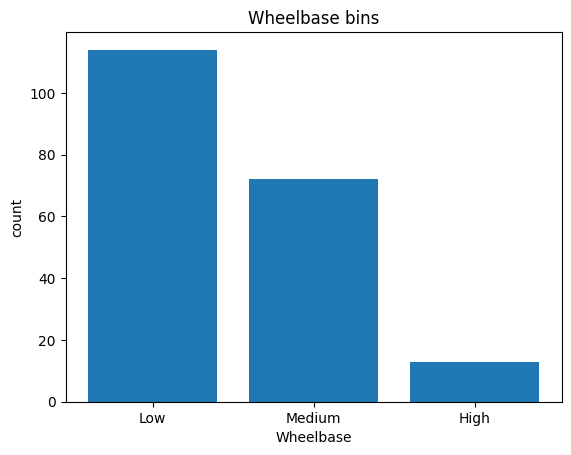

In [49]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot
pyplot.bar(group_names, df["wheelbase-binned"].value_counts())

# set x/y labels and plot title
plt.pyplot.xlabel("Wheelbase")
plt.pyplot.ylabel("count")
plt.pyplot.title("Wheelbase bins")